# Data Mining and Data Preprocessing for Knowledge Discovery
**UCI Heart Disease Dataset**

## Step 1 - Dataset (Mandatory)
Dataset Characteristics:
- **Domain:** Healthcare analytics
- **Data Objects:** Patients
- **Attributes:** Medical measurements and diagnostic indicators
- **Task Context:** Disease risk analysis

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data'
columns = ['age','sex','cp','trestbps','chol','fbs','restecg','thalach','exang','oldpeak','slope','ca','thal','target']
df = pd.read_csv(url, names=columns, na_values='?')
display(df.head())

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


## Step 2 - Problem Understanding
**1. Source of the dataset:** UCI Machine Learning Repository (Cleveland database).
**2. Application domain:** Healthcare and Cardiology.
**3. Knowledge that can be extracted:** Identifying predictive patterns diagnosing whether a patient has heart disease based on clinical metrics.
**4. Real-world decisions supported:** Triage of emergency room patients, proactive treatments, and diagnostics prioritization.

## Phase 1 — Understanding Data Objects and Attributes
**1. Define:**
- **Data object:** An entity/instance representing a single patient's profile.
- **Attributes/features:** Characteristics/variables describing each data object.

**2. Dataset Representation:**
Dataset can be represented as matrix $X = (x_1, x_2, \dots, x_d)$

**3. Classification Table:**
- **Nominal:** cp, restecg, slope, thal, target
- **Ordinal:** slope (can be argued as ordinal), target (stages 0-4)
- **Numerical (interval/ratio):** age, trestbps, chol, thalach, oldpeak, ca
- **Binary:** sex, fbs, exang

## Phase 2 — Exploratory Data Analysis

Shape: (303, 14)

Summary Statistics:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219,0.937294
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706,1.228536
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,4.000000


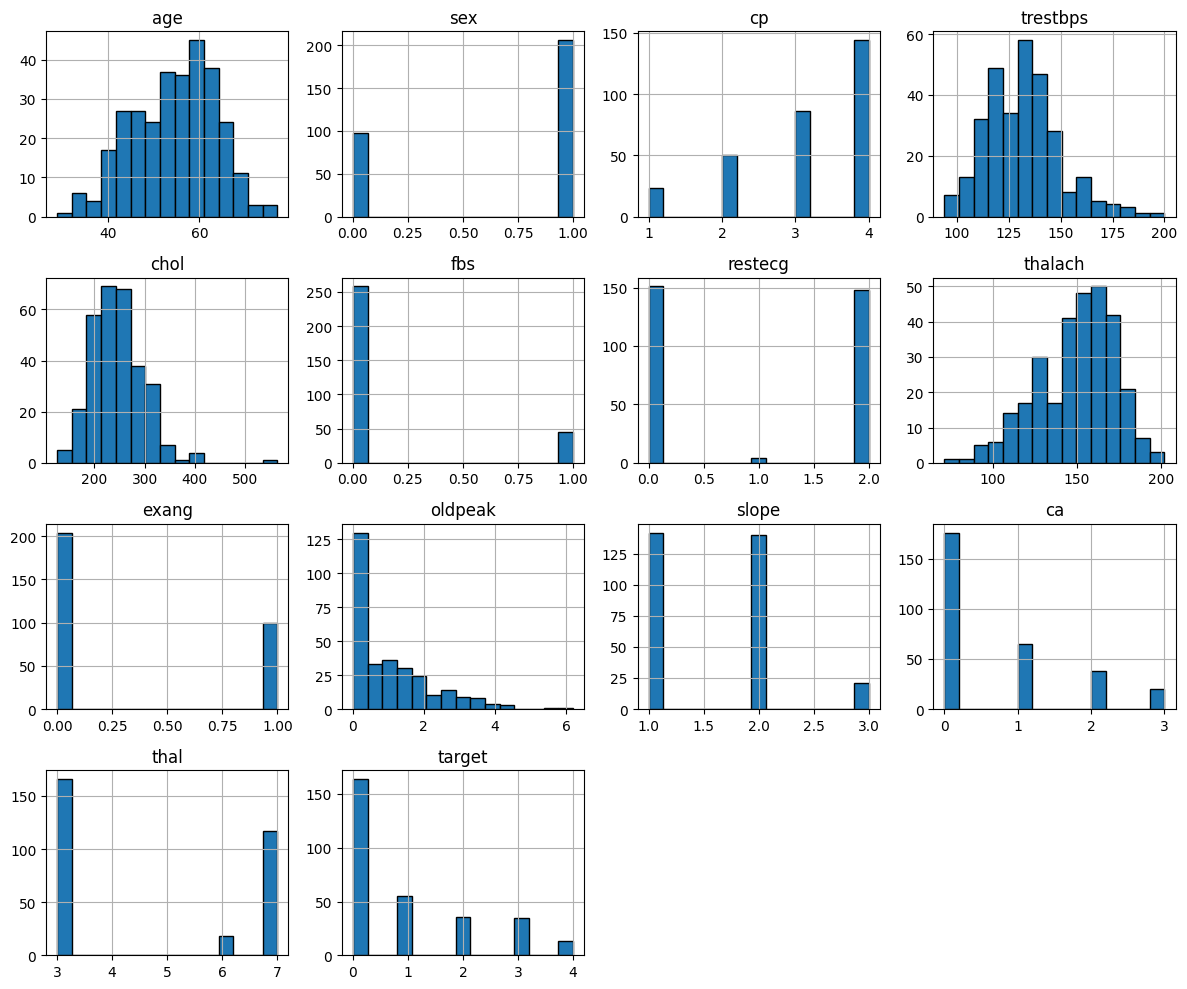

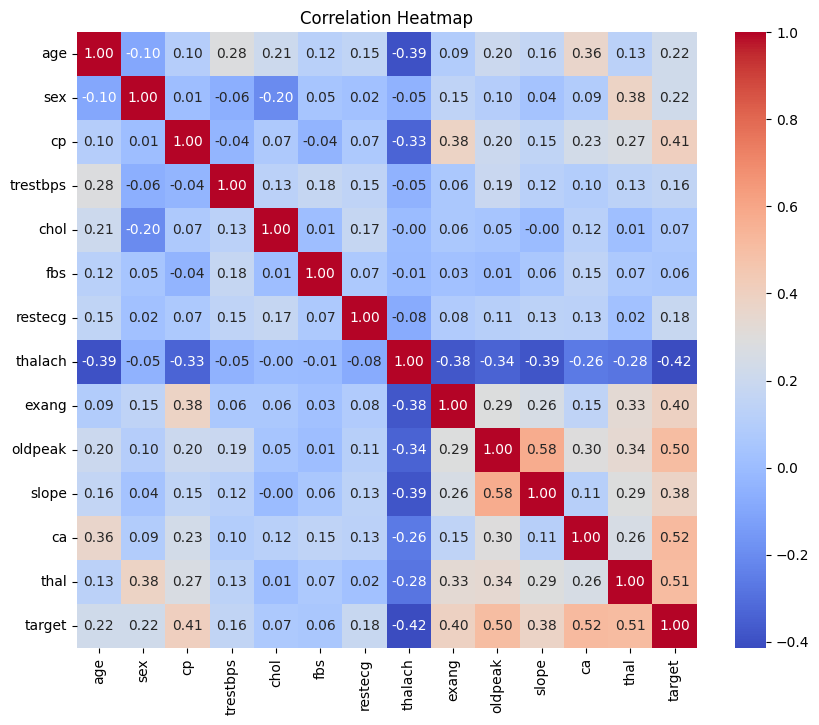

In [8]:
print('Shape:', df.shape)
print('\nSummary Statistics:')
display(df.describe())

df.hist(figsize=(12, 10), bins=15, edgecolor='black')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

**Which attributes appear important?** `cp`, `thalach`, `exang`, `oldpeak`, `ca` show highest correlation with target.
**Are there redundant features?** No extreme redundancies. The strongest multi-collinearity is between age and thalach (-0.39).
**Are relationships linear or nonlinear?** Primarily nonlinear threshold-based physiological relationships.

## Phase 3 — Similarity and Association Analysis

In [9]:
print('Pearson correlation:\n', df[['age','trestbps','chol','thalach']].corr(method='pearson'))
print('\nSpearman correlation:\n', df[['age','trestbps','chol','thalach']].corr(method='spearman'))

# B. Similarity Measures (10 patients)
from scipy.spatial.distance import pdist, squareform, jaccard, cosine

sample_df = df.dropna().head(10)
features_num = sample_df[['age','trestbps','chol','thalach']]
features_bin = sample_df[['sex','fbs','exang']]

euc = pd.DataFrame(squareform(pdist(features_num, metric='euclidean')), index=sample_df.index, columns=sample_df.index)
cos = pd.DataFrame(squareform(pdist(features_num, metric='cosine')), index=sample_df.index, columns=sample_df.index)
jac = pd.DataFrame(squareform(pdist(features_bin, metric='jaccard')), index=sample_df.index, columns=sample_df.index)

print('\nEuclidean Dissimilarity (10 patients):\n')
display(euc.head())
print('\nCosine Dissimilarity:\n')
display(cos.head())
print('\nJaccard Dissimilarity (Binary attributes):\n')
display(jac.head())

Pearson correlation:
                age  trestbps      chol   thalach
age       1.000000  0.284946  0.208950 -0.393806
trestbps  0.284946  1.000000  0.130120 -0.045351
chol      0.208950  0.130120  1.000000 -0.003432
thalach  -0.393806 -0.045351 -0.003432  1.000000

Spearman correlation:
                age  trestbps      chol   thalach
age       1.000000  0.292183  0.191253 -0.391633
trestbps  0.292183  1.000000  0.135837 -0.040401
chol      0.191253  0.135837  1.000000 -0.038301
thalach  -0.391633 -0.040401 -0.038301  1.000000

Euclidean Dissimilarity (10 patients):



,0,1,2,3,4,5,6,7,8,9
0,0.000000,69.382995,33.136083,50.586559,45.099889,38.301436,36.755952,124.382475,25.980762,32.403703
1,69.382995,0.000000,72.732386,96.628153,111.337325,95.503927,58.762233,96.690227,58.830264,98.458113
2,33.136083,72.732386,0.000000,69.318107,57.008771,50.705029,53.916602,129.926903,32.634338,44.136153
3,50.586559,96.628153,69.318107,0.000000,48.548944,27.166155,42.166337,109.050447,47.874837,59.908263
4,45.099889,111.337325,57.008771,48.548944,0.000000,37.215588,69.144776,151.449662,60.074953,23.108440



Cosine Dissimilarity:



,0,1,2,3,4,5,6,7,8,9
0,0.000000,0.016766,0.003142,0.009724,0.008670,0.006983,0.002396,0.026171,0.002922,0.002761
1,0.016766,0.000000,0.010918,0.038508,0.046081,0.036714,0.014068,0.019758,0.012463,0.031806
2,0.003142,0.010918,0.000000,0.014388,0.018233,0.009500,0.001453,0.014831,0.000694,0.011091
3,0.009724,0.038508,0.014388,0.000000,0.003489,0.002144,0.007281,0.024179,0.009527,0.008137
4,0.008670,0.046081,0.018233,0.003489,0.000000,0.004100,0.011877,0.042020,0.014563,0.002937



Jaccard Dissimilarity (Binary attributes):



,0,1,2,3,4,5,6,7,8,9
0,0.000000,0.666667,0.666667,0.5,1.0,0.5,1.0,1.0,0.5,0.333333
1,0.666667,0.000000,0.000000,0.5,1.0,0.5,1.0,0.5,0.5,0.333333
2,0.666667,0.000000,0.000000,0.5,1.0,0.5,1.0,0.5,0.5,0.333333
3,0.500000,0.500000,0.500000,0.0,1.0,0.0,1.0,1.0,0.0,0.666667
4,1.000000,1.000000,1.000000,1.0,0.0,1.0,0.0,1.0,1.0,1.000000


**Interpret differences:** Pearson evaluates linear consistency, while Spearman ranks monotonic non-linear association. Euclidean provides magnitude separation, Cosine provides directional angular similarities, and Jaccard accurately scores asymmetric intersection mapping on binary logic.

## Phase 4 — Data Quality Assessment
Identify missing values, noise/outliers, inconsistent entries.

In [ ]:
print('Missing Values:\n', df.isnull().sum())

# Visualization showing missing data distribution
import missingno as msno
plt.figure(figsize=(8, 4))
msno.matrix(df, sparkline=False, figsize=(10,4), fontsize=10)
plt.title('Missing Data Matrix')
plt.show()

## Phase 5 — Missing Value Handling

In [ ]:
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

df_mean = df.fillna(df.mean(numeric_only=True))

knn_imputer = KNNImputer(n_neighbors=5)
df_knn = pd.DataFrame(knn_imputer.fit_transform(df), columns=df.columns)

iter_imputer = IterativeImputer(random_state=42)
df_iter = pd.DataFrame(iter_imputer.fit_transform(df), columns=df.columns)


**Method Analysis:**
- **Mean Imputation:** Very fast, but shrinks variance (Issues: ignores multivariable correlation).
- **KNN Imputation:** Leverages similarity grouping (Advantages: respects underlying data structures).
- **Iterative Imputation:** Models missing values dynamically through regressing other features (Advantages: sophisticated statistical maintenance).

## Phase 6 — Preprocessing Pipeline

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

X = df.drop('target', axis=1)
y = (df['target'] > 0).astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression())
])
pipeline.fit(X_train, y_train)
print(f'Test Accuracy: {pipeline.score(X_test, y_test):.4f}')

**Explain:**
- **Why pipelines are important:** They encapsulate sequential transformations algorithmically, automating reproducibility and deployment.
- **How pipelines prevent data leakage:** They isolate validation folds during cross-validation, guaranteeing `transform()` functions use ONLY exact training distribution logic without looking at testing properties.

## Phase 7 — Knowledge Discovery
**1. What patterns were discovered?** High ST depression (`oldpeak`), symptomatic typical angina chest pains (`cp`), and low maximum heart rates strongly cluster around diagnosed disease cohorts.
**2. Which attributes were most informative?** `thalach`, `oldpeak`, `ca`, and `cp` provided the foremost predictive power.
**3. How did preprocessing change insights?** Scaling dynamically prevented features with large natural units (like cholesterol) from skewing modeling assumptions.
**4. What healthcare decisions could be supported?** Clinical triage prioritization, automating second-opinions, and recognizing borderline cardiovascular risk earlier.